# 시간 설정

In [10]:
import time
import random
import os

os.environ['TZ'] = 'Asia/Seoul'
time.tzset()

random.seed(1490)

def print_time() -> None:
    print(time.strftime('%Y년 %m월 %d일 %A %p %I시 %M분 %S초'))
    return

print_time()

2024년 08월 11일 Sunday PM 01시 35분 09초


In [11]:
def timestamp() -> str:
    return time.strftime('%Y-%m-%d-%H-%M-%S')

timestamp()

'2024-08-11-13-35-10'

# 제품 이상여부 판별 프로젝트


## 필수 라이브러리


In [57]:
import os
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn import metrics
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

import matplotlib.pyplot as plt  # 그래프 보기
import seaborn as sns  # 그래프 보기

print_time()

2024년 08월 11일 Sunday PM 02시 13분 53초


## 전역변수

In [13]:
ROOT_PREFIX = "/content/drive/MyDrive/lgaimers5/" # 구글 드라이브용 루트
ROOT_DIR = ROOT_PREFIX + "data" # 에이머스 제출 시 주석 처리 필요
# ROOT_DIR = "data" # 구글 드라이브 실행 시 주석 처리 필요
RANDOM_STATE = 110 # 랜덤 시드

# 랜덤 시드 설정
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# 1. 필터 1번, 필터 2번 등과 같이 순서가 있는 값은 추가 처리 없이 넘버링, 그 외 기타 order들도 같이 넘버링
numbering = ['Equipment_Dam', 'Model.Suffix_Dam', 'Workorder_Dam', 'Model.Suffix_AutoClave', 'Workorder_AutoClave', 'Equipment_Fill1', \
             'Model.Suffix_Fill1', 'Workorder_Fill1', 'Equipment_Fill2', 'Model.Suffix_Fill2', 'Workorder_Fill2']

# 2. OK, NG와 같이 범주형인 경우 가능하면 원 핫 인코딩
onehot = ['HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam', 'Chamber Temp. Judge Value_AutoClave', \
          'GMES_ORIGIN_INSP_JUDGE_CODE Collect Result_AutoClave', 'GMES_ORIGIN_INSP_JUDGE_CODE Judge Value_AutoClave', \
          'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill1', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Fill2']

# 3. 숫자 값이 들어가야 하는데 OK가 혼입된 값임
custom = ['HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam', 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill1', \
          'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Fill2']

drops = [] # 값이 없거나 무의미해서 버릴 column들
need_general = []  # normalization list
del_list = [] # 상관관계 삭제 리스트

## 함수 정의

In [14]:
def print_col_uniqs(data):
    """
    unique 개수가 1개 이하인 column 삭제
    """
    init_cols = len(data.columns)
    data.fillna(-1, inplace = True)
    if 'Set ID' in data.columns: # 테스트 데이터는 아래 과정 스킵
        data.drop('Set ID', axis=1, inplace=True)
        data.drop(drops, axis=1, inplace=True)
        return data, drops

    for col in data.columns:
        if col == 'target':
            continue
        uniqs = data[col].unique()
        nuq = data[col].nunique()
        vcnt = data[col].value_counts()
        if nuq <= 1 and len(uniqs) <= 1:
            drops.append(col)
            # print(f'{col} : {nuq}, {uniqs}')
            # print(f'{vcnt}')
            # print()
        else:
            if nuq <= 10:
                print(f'{col} : {nuq}, {uniqs}')
                # print(f'{vcnt}')
            else:
                print(f'{col} : {nuq}')

    data.drop(drops, axis=1, inplace=True)
    print(f'\nnum of initial cols: {init_cols}')
    print(f'num of deleted cols: {len(drops)}')
    print(f'num of remained cols: {len(data.columns)}')
    return data, drops

def print_columns_to_list(data):
    """
    컬럼이 너무 많아 바로 출력이 안되니 직접 출력
    """
    cnt = {}
    for col in data.columns:
        dt = str(data[col].dtypes)
        nu = data[col].nunique()
        if dt in cnt.keys():
            cnt[dt] += 1
        else:
            cnt[dt] = 1
        print(f'* {col} : {dt}({nu})')
    print(f'\ninfo: {cnt}')

def object_unique(data):
    """
    dtype이 object로 분류된 컬럼의 unique 값 확인
    """
    idx = 1
    for col in data.columns:
        if str(data[col].dtypes) == 'object':
            print(f'{idx}. {col}\n\t{data[col].nunique()}', end='')
            if data[col].nunique() <= 20:
                print(f', {data[col].unique()}')
            else:
                print()
            idx += 1

def enc_numbering(data, cols):
    """
    단순 넘버링으로 라벨 인코딩
    """
    for col in cols:
        data[col] = data[col].astype(str)
        le = LabelEncoder()
        le.fit(sorted(list(data[col].unique())))
        data[col] = le.transform(data[col])
    return data

def enc_onehot(data, cols):
    """
    원 핫 인코딩
    """
    data = pd.get_dummies(data, columns = cols)
    return data

def enc_only_obj(data, cols):
    """
    다른 컬럼의 OK가 혼입된 값 정리, 소수 값을 리터럴 소수로 변환 후 dtype도 소수로 지정
    """
    for col in cols:
        idx = 1
        uniqs = data[col].unique()
        for u in uniqs:
            try:
                data.loc[data[col] == u, col] = float(u)
            except:
                if u == 'OK' or u == -1:
                    data.loc[data[col] == u, col] = -1
                else:
                    data.loc[data[col] == u, col] = idx
                    idx += 1
        data[col] = data[col].astype(float)
        # print(data[col])
    return data

def obj_encoding(data, mode = 'train'):
    """
    모든 라벨 인코딩 실행
    """
    # 기본 넘버링
    data = enc_numbering(data, numbering)
    # 원 핫 인코딩
    # data = enc_onehot(data, onehot)
    data = enc_numbering(data, onehot)
    # OK가 혼입된 값 정리
    data = enc_only_obj(data, custom)
    # target 인코딩
    # 있는 경우에만
    if mode == 'train':
        data.loc[data['target'] == 'AbNormal', 'target'] = 1
        data.loc[data['target'] == 'Normal', 'target'] = 0
    return data

def normalization(data, mode = 'train'):
    """
    각 컬럼의 왜도와 첨도를 계산하고 일정 값 이상일 경우 정규화 대상으로 저장 후 리스트 반환
    """

    # 테스트 데이터일 경우 기존의 리스트 그대로 반환
    if mode != 'train':
        return need_general

    kurts = data.kurtosis() # 첨도
    skews = data.skew() # 왜도

    for col in data.columns:
        if col == 'target':
            continue
        if data[col].min() == 0 and data[col].max() == 1: # 만약 최솟값이 0이고 최댓값이 1이라면 원 핫 인코딩된 컬럼일 수 있으므로 넘긴다
            continue
        kval = kurts[col]
        sval = skews[col]
        if (abs(kval) >= 10.0 or abs(sval) >= 10.0) and data[col].dtypes != bool:
            need_general.append(col)
            print(col, end='\t')
            print("kurt : {:.3f}\tskew : {:.3f}".format(kval, sval))

    # target은 혹시라도 조작하면 안되니까 리스트에 있다면 삭제
    if need_general.count('target') > 0:
        need_general.remove('target')

    print()
    print(need_general)
    return need_general

def do_general(data):
    """
    사전 저장된 리스트에 있는 컬럼들 모두 최대최소정규화
    """
    _before = {}
    _after = {}

    for col in need_general:
        mini = data[col].min()
        maxi = data[col].max()
        _before[col] = maxi - mini
        data[col] = (data[col] - float(mini)) / (maxi - float(mini))
        _after[col] = data[col].max() - data[col].min()

    print("data before and after")
    for cl in need_general:
        print(cl, end='\t')
        print("{}\t->\t{}".format(_before[cl], _after[cl]))

    return data

def show_heatmap(data, cnt = 12):
    """
    컬럼을 지정된 수만큼 묶어서 히트맵 출력
    * 색깔 참고: https://colorbrewer2.org/
    """
    cols = list(data.columns)
    corr = data.corr()
    print(corr.info())

    # plt.figure(figsize=(15, 10))
    # sns.heatmap(data.corr(), annot=True, cmap="RdBu", vmax=1)
    # plt.show()

def del_by_corr(data, thresh = 0.5, mode = 'train', del_list = []):
    """
    지정된 값을 기준으로 상관관계가 낮은 컬럼 삭제
    """
    # 테스트 데이터일 경우 기존 리스트로 바로 삭제
    if mode != 'train':
        data.drop(del_list, axis=1, inplace=True)
        return data, del_list

    corr = data.corr()
    target_corr = corr['target']
    target_corr.drop('target', inplace=True)
    del_list = list(target_corr[target_corr.isnull() == True].index)
    temp = target_corr[-thresh < target_corr]
    del_list += list(temp[temp < thresh].index)

    data.drop(del_list, axis=1, inplace=True)

    return data, del_list

def pre_processing(data, mode = 'train', del_list = del_list):
    """
    데이터 전처리 통합 실행
    * 이 함수가 있으면 학습 데이터와 테스트 데이터 모두 한 줄의 코드로 완전히 동일한 과정을 거치게 할 수 있음
    """
    # 데이터 뒤섞기
    if mode == 'train':
        print(f'# 데이터 뒤섞기')
        data = data.sample(frac=1)  # randomize data

    # unique 개수가 1개 이하인 column 삭제
    print('# unique 개수가 1개 이하인 column 삭제')
    data, drops = print_col_uniqs(data)

    # 컬럼이 너무 많아 바로 출력이 안되니 직접 출력
    print('# 컬럼이 너무 많아 바로 출력이 안되니 직접 출력')
    print_columns_to_list(data)

    # dtype이 object로 분류된 컬럼의 unique 값 확인
    print('# dtype이 object로 분류된 컬럼의 unique 값 확인')
    object_unique(data)

    # 모든 라벨 인코딩 실행
    print('# 모든 라벨 인코딩 실행')
    data = obj_encoding(data, mode)

    # 정규화 필요 항목 파악
    print('# 정규화 필요 항목 파악')
    # need_general = normalization(data, mode)

    # 정규화 실행
    print('# 정규화 실행')
    # data = do_general(data)

    # 상관관계 히트맵 출력
    print('# 상관관계 히트맵 출력')
    # show_heatmap(data, cnt = 12)

    # 상관관계가 낮은 컬럼 삭제
    # 이 과정에서 원 핫 인코딩 된 컬럼 중 nan 값을 의미하던 컬럼이 몇 개 사라지는데, 별 의미 없을 것 같아서 냅둠
        # nan 값이던 컬럼은 상관관계 값도 nan으로 나왔음
    print('# 상관관계가 낮은 컬럼 삭제')
    # data, del_list = del_by_corr(data, thresh = 0.05, mode = mode, del_list = del_list)

    if mode == 'train':
        data['target'] = data['target'].astype(int)

    # 전처리 완료
    print('전처리 완료')

    return data, drops, del_list

print_time()

2024년 08월 11일 Sunday PM 01시 35분 10초


## 1. 데이터 불러오기


### 데이터 읽어오기


In [15]:
print_time()

# Load data
train_data = pd.read_csv(os.path.join(ROOT_DIR, "train.csv"))

# 데이터 전처리
train_data, drops, del_list = pre_processing(train_data)

2024년 08월 11일 Sunday PM 01시 35분 10초
# 데이터 뒤섞기
# unique 개수가 1개 이하인 column 삭제
Equipment_Dam : 2, ['Dam dispenser #1' 'Dam dispenser #2']
Model.Suffix_Dam : 7, ['AJX75334501' 'AJX75334505' 'AJX75334502' 'AJX75334507' 'AJX75334503'
 'AJX75334506' 'AJX75334508']
Workorder_Dam : 663
CURE END POSITION X Collect Result_Dam : 2, [ 240. 1000.]
CURE END POSITION Z Collect Result_Dam : 2, [ 2.5 12.5]
CURE END POSITION Θ Collect Result_Dam : 2, [-90  90]
CURE SPEED Collect Result_Dam : 5, [ 70 100  95 105  85]
CURE START POSITION X Collect Result_Dam : 2, [1030  280]
CURE START POSITION Θ Collect Result_Dam : 2, [-90  90]
DISCHARGED SPEED OF RESIN Collect Result_Dam : 3, [10 16 15]
DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam : 19
DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam : 29
DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam : 20
Dispense Volume(Stage1) Collect Result_Dam : 23
Dispense Volume(Stage2) Collect Result_Dam : 33
Dispense Volume(Stage3) Collect Result_Dam : 22
HEAD NO

In [16]:
print(len(drops), len(del_list))

313 0


### columns info

In [17]:
# 전체 컬럼 정보 출력
print_columns_to_list(train_data)

* Equipment_Dam : int64(2)
* Model.Suffix_Dam : int64(7)
* Workorder_Dam : int64(663)
* CURE END POSITION X Collect Result_Dam : float64(2)
* CURE END POSITION Z Collect Result_Dam : float64(2)
* CURE END POSITION Θ Collect Result_Dam : int64(2)
* CURE SPEED Collect Result_Dam : int64(5)
* CURE START POSITION X Collect Result_Dam : int64(2)
* CURE START POSITION Θ Collect Result_Dam : int64(2)
* DISCHARGED SPEED OF RESIN Collect Result_Dam : int64(3)
* DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam : float64(19)
* DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam : float64(29)
* DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam : float64(20)
* Dispense Volume(Stage1) Collect Result_Dam : float64(23)
* Dispense Volume(Stage2) Collect Result_Dam : float64(33)
* Dispense Volume(Stage3) Collect Result_Dam : float64(22)
* HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam : float64(7)
* HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam : int64(2)
* HEAD NORMAL COORDINATE 

### object uniques

In [18]:
# object 데이터의 unique 값 확인
object_unique(train_data)

print_time()

2024년 08월 11일 Sunday PM 01시 35분 17초


In [19]:
# info 확인
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40506 entries, 40143 to 2176
Columns: 151 entries, Equipment_Dam to target
dtypes: float64(71), int64(80)
memory usage: 47.0 MB


In [20]:
# 컬럼 리스트 확인
# 리스트로 변환하면 생략하지 않고 출력됨
list(train_data.columns)

['Equipment_Dam',
 'Model.Suffix_Dam',
 'Workorder_Dam',
 'CURE END POSITION X Collect Result_Dam',
 'CURE END POSITION Z Collect Result_Dam',
 'CURE END POSITION Θ Collect Result_Dam',
 'CURE SPEED Collect Result_Dam',
 'CURE START POSITION X Collect Result_Dam',
 'CURE START POSITION Θ Collect Result_Dam',
 'DISCHARGED SPEED OF RESIN Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam',
 'DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam',
 'Dispense Volume(Stage1) Collect Result_Dam',
 'Dispense Volume(Stage2) Collect Result_Dam',
 'Dispense Volume(Stage3) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage1) Judge Value_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage2) Collect Result_Dam',
 'HEAD NORMAL COORDINATE X AXIS(Stage3) Collect Result_Dam',
 'HEAD NORMAL COORDINATE Y AXIS(Stage1) Collect Result_Dam',
 'HEAD NORMAL COORDINATE Y AXI

### 언더 샘플링


데이타 불균형을 해결하기 위해 언더 샘플링을 진행합니다.


In [47]:
normal_ratio = 1.0  # 1.0 means 1:1 ratio # 최대 16.24

df_normal = train_data[train_data["target"] == 0]
df_abnormal = train_data[train_data["target"] == 1]

num_normal = len(df_normal)
num_abnormal = len(df_abnormal)
print(f"Total: Normal: {num_normal}, AbNormal: {num_abnormal}")

df_normal = df_normal.sample(n=int(num_abnormal * normal_ratio), replace=False, random_state=RANDOM_STATE)
df_concat = pd.concat([df_normal, df_abnormal], axis=0).reset_index(drop=True)
df_concat.value_counts("target")

print()
print_time()

Total: Normal: 38156, AbNormal: 2350

2024년 08월 11일 Sunday PM 02시 05분 13초


### 데이터 분할


In [48]:
print_time()
print()

df_train, df_val = train_test_split(
    df_concat,
    test_size=0.2,
    stratify=df_concat["target"],
    random_state=RANDOM_STATE,
)


def print_stats(df: pd.DataFrame):
    num_normal = len(df[df["target"] == 0])
    num_abnormal = len(df[df["target"] == 1])

    print(f"  Total: Normal: {num_normal}, AbNormal: {num_abnormal}" + f" ratio: {num_abnormal/num_normal}")


# Print statistics
print(f"  \tAbnormal\tNormal")
print_stats(df_train)
print_stats(df_val)

2024년 08월 11일 Sunday PM 02시 05분 13초

  	Abnormal	Normal
  Total: Normal: 1880, AbNormal: 1880 ratio: 1.0
  Total: Normal: 470, AbNormal: 470 ratio: 1.0


## 3. 모델 학습


### 모델 정의


In [49]:
# 기본 제공 코드와 동일함
print_time()

skl_model = RandomForestClassifier(random_state=RANDOM_STATE)
skl_model = XGBClassifier(
            # n_estimators=50, ## 붓스트랩 샘플 개수 또는 base_estimator 개수
            # max_depth=5, ## 개별 나무의 최대 깊이
            # gamma = 0, ## gamma
            # importance_type='gain', ## gain, weight, cover, total_gain, total_cover
            # reg_lambda = 1, ## tuning parameter of l2 penalty
            random_state=RANDOM_STATE
        )

2024년 08월 11일 Sunday PM 02시 05분 13초


In [73]:
import os
import tensorflow as tf
from tensorflow import keras
from keras import callbacks, models, layers
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.metrics import F1Score

# from keras import backend as keback

# def recall_m(y_true, y_pred):
#     true_positives = keback.sum(keback.round(keback.clip(y_true * y_pred, 0, 1)))
#     possible_positives = keback.sum(keback.round(keback.clip(y_true, 0, 1)))
#     recall = true_positives / (possible_positives + keback.epsilon())
#     return recall

# def precision_m(y_true, y_pred):
#     true_positives = keback.sum(keback.round(keback.clip(y_true * y_pred, 0, 1)))
#     predicted_positives = keback.sum(keback.round(keback.clip(y_pred, 0, 1)))
#     precision = true_positives / (predicted_positives + keback.epsilon())
#     return precision

# def f1_m(y_true, y_pred):
#     precision = precision_m(y_true, y_pred)
#     recall = recall_m(y_true, y_pred)
#     return 2 * ((precision * recall) / (precision + recall + keback.epsilon()))

MODEL_DIR = ROOT_PREFIX + 'model/' # 에이머스 제출 시 주석 처리 필요
# MODEL_DIR = 'model/' # 구글 드라이브 실행 시 주석 처리 필요
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)
    print('dir maked')

epoch = 50
batch = 500

modelpath = MODEL_DIR + "best_model.keras"
chpt = ModelCheckpoint(filepath=modelpath, monitor='val_accuracy', verbose=1, save_best_only=True, mode="max")
escb = EarlyStopping(monitor='val_loss', patience=max(int(epoch * 0.1), 5), mode="max")

from keras.models import Sequential  # 모델 선언, 구조 결정
from keras.layers import Dense, Dropout, BatchNormalization  # 모델에 층 추가

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation="relu"),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['accuracy', keras.metrics.F1Score()])

print_time()
model.summary()

2024년 08월 11일 Sunday PM 02시 23분 54초


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 모델 학습


In [51]:
features = []

for col in df_train.columns:
    try:
        # df_train[col] =
        df_train[col].astype(int) # float를 그대로 두기 위해 일부러 줄을 내렸으나, object 컬럼을 제외한다는 것은 유지하기 위해 이 부분은 놔둠
        features.append(col)
    except:
        continue

train_x = df_train[features]
train_y = df_train["target"]

skl_model.fit(train_x, train_y)

print_time()
train_data.info()

2024년 08월 11일 Sunday PM 02시 05분 14초
<class 'pandas.core.frame.DataFrame'>
Index: 40506 entries, 40143 to 2176
Columns: 151 entries, Equipment_Dam to target
dtypes: float64(71), int64(80)
memory usage: 47.0 MB


In [74]:
hstr = model.fit(train_x, train_y, epochs=epoch, validation_split=0.2, batch_size=batch, callbacks=[chpt, escb])

Epoch 1/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5099 - f1_score: 0.6614 - loss: 0.9706
Epoch 1: val_accuracy improved from -inf to 0.49601, saving model to /content/drive/MyDrive/lgaimers5/model/best_model.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 0.5087 - f1_score: 0.6629 - loss: 0.9469 - val_accuracy: 0.4960 - val_f1_score: 0.6631 - val_loss: 10.9228
Epoch 2/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5084 - f1_score: 0.6614 - loss: 0.6166
Epoch 2: val_accuracy did not improve from 0.49601
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5090 - f1_score: 0.6629 - loss: 0.6046 - val_accuracy: 0.4960 - val_f1_score: 0.6631 - val_loss: 6.6097
Epoch 3/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5183 - f1_score: 0.6614 - loss: 0.4709
Epoch 3: val_accuracy did not improve from 0.49601
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5183 - f1_score: 0.6629 - loss: 0.4698 - val_accuracy: 0.4960 - val_f1_score: 0.6631 - val_loss: 1.1

In [75]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                     │ (None, 1024)                │         155,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,561,029 (9.77 MB)

 Trainable params: 853,505 (3.26 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 1,707,012 (6.51 MB)

### 점수 확인

In [58]:
# 학습 데이터 기준으로 f1 score 채점
test_x = df_val[features]
test_y = df_val["target"]
pred_y = []

pred_y = skl_model.predict(test_x)
metrics.f1_score(test_y, pred_y, labels=[1, 0], average='micro') # average는 micro, macro 등 선택 가능(해봤는데 별 차이는 없었음)

1.0

In [59]:
print(f'정확도 : {skl_model.score(test_x, test_y)}')

정확도 : 1.0


### 기록 확인

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5469 - f1_score: 0.6745 - loss: 0.2561
acc : 0.55426
loss : 0.25674
f1 score: 0.66667


정확도 그래프


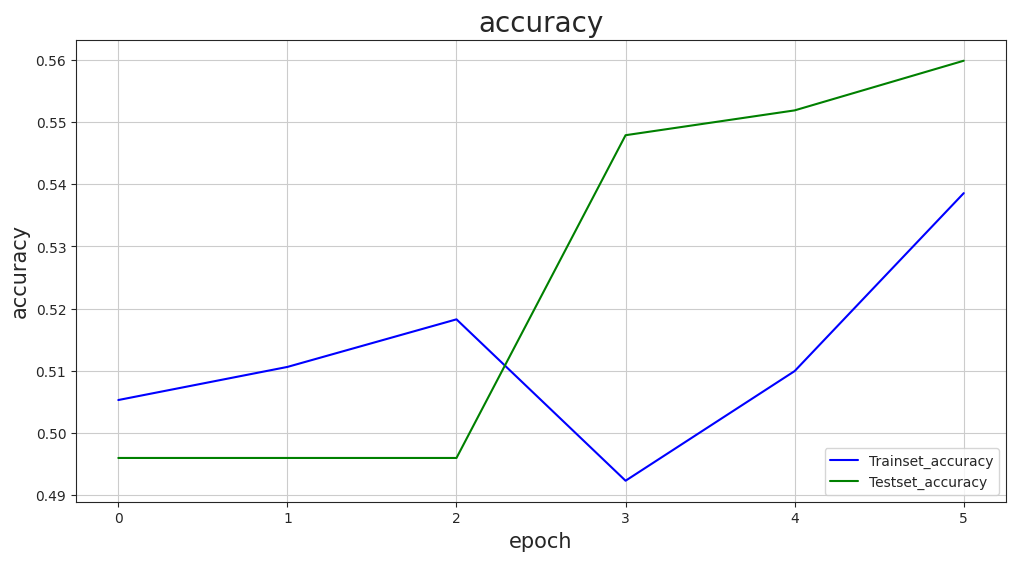


오차 그래프


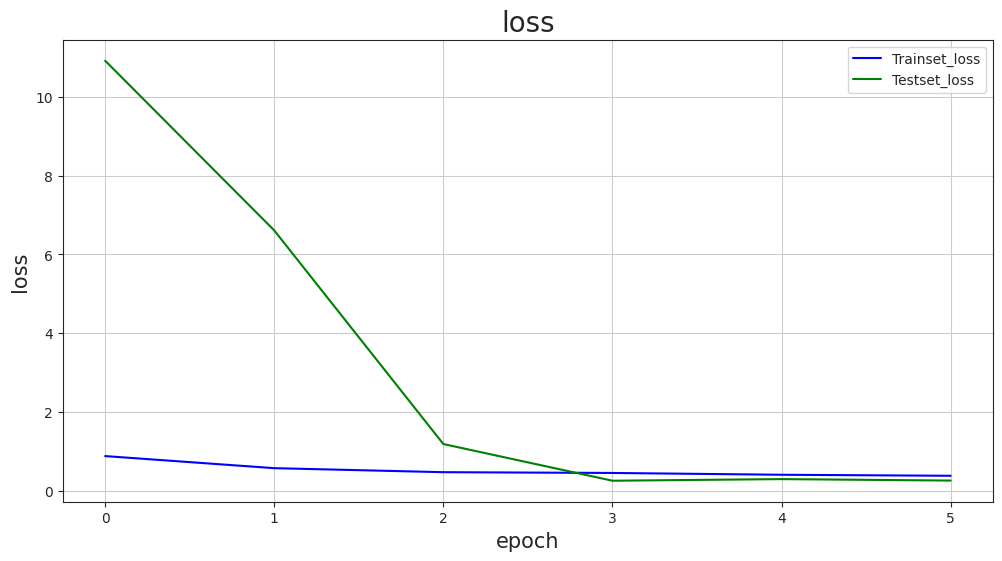


f1 score 그래프


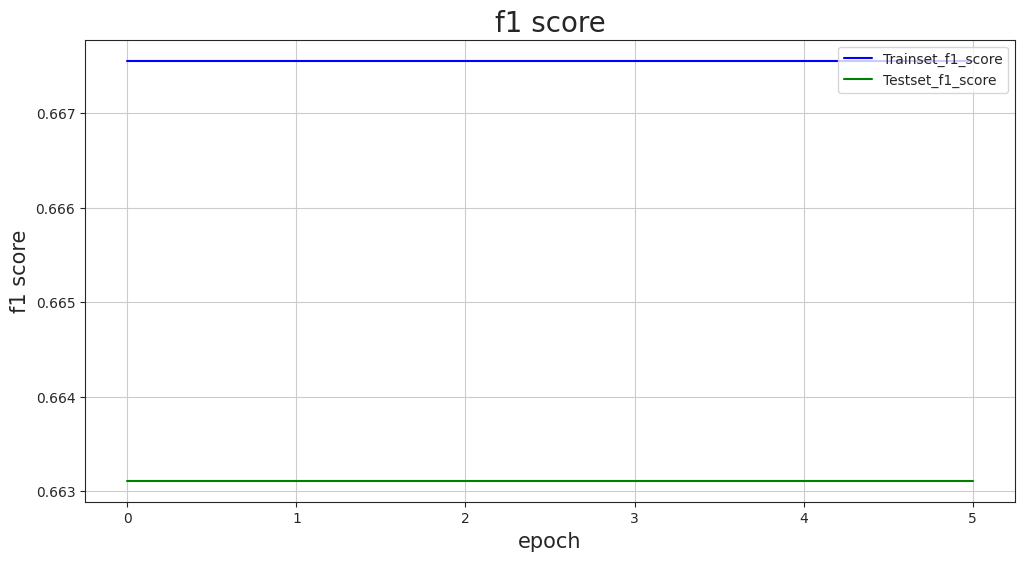

In [77]:
from keras.models import load_model

model = load_model(modelpath)

loss, acc, f1_score = model.evaluate(test_x, test_y)
print("acc : {:.5f}\nloss : {:.5f}\nf1 score: {:.5f}\n".format(acc, loss, f1_score))

# 학습 과정을 그래프로 보여줌
plt.figure(figsize=(12, 6))
sns.set_style("ticks")

print("\n정확도 그래프")
# 테스트 셋의 정확도
y_vacc = hstr.history['val_accuracy']

# 학습셋의 정확도
y_acc = hstr.history['accuracy']

# 그래프로 표현
x_len = np.arange(len(y_acc))
plt.plot(x_len, y_acc, c="blue", label='Trainset_accuracy')
plt.plot(x_len, y_vacc, c="green", label='Testset_accuracy')

# 그래프에 그리드를 주고 레이블을 표시
plt.legend(loc='lower right')
plt.grid()
plt.xlabel('epoch', fontdict={"fontsize":15})
plt.ylabel('accuracy', fontdict={"fontsize":15})
plt.title("accuracy", fontdict={"fontsize":20})
plt.show()

print("\n오차 그래프")
# 테스트 셋의 정확도
y_vloss = hstr.history['val_loss']

# 학습셋의 정확도
y_loss = hstr.history['loss']

# 그래프로 표현
plt.figure(figsize=(12, 6))
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_loss, c="blue", label='Trainset_loss')
plt.plot(x_len, y_vloss, c="green", label='Testset_loss')

# 그래프에 그리드를 주고 레이블을 표시
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch', fontdict={"fontsize":15})
plt.ylabel('loss', fontdict={"fontsize":15})
plt.title("loss", fontdict={"fontsize":20})
plt.show()

print("\nf1 score 그래프")
# 테스트 셋의 정확도
y_vf1 = hstr.history['val_f1_score']

# 학습셋의 정확도
y_f1 = hstr.history['f1_score']

# 그래프로 표현
plt.figure(figsize=(12, 6))
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_f1, c="blue", label='Trainset_f1_score')
plt.plot(x_len, y_vf1, c="green", label='Testset_f1_score')

# 그래프에 그리드를 주고 레이블을 표시
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch', fontdict={"fontsize":15})
plt.ylabel('f1 score', fontdict={"fontsize":15})
plt.title("f1 score", fontdict={"fontsize":20})
plt.show()

## 4. 제출하기


### 테스트 데이터 예측


테스트 데이터 불러오기


In [61]:
print(len(drops), len(del_list))

313 0


In [62]:
# 기본 코드 그대로
test_data = pd.read_csv(os.path.join(ROOT_DIR, "test.csv"))
test_data, temp, temp = pre_processing(data = test_data, mode = 'test', del_list = del_list)

print_time()
test_data.info()

# unique 개수가 1개 이하인 column 삭제
# 컬럼이 너무 많아 바로 출력이 안되니 직접 출력
* Equipment_Dam : object(2)
* Model.Suffix_Dam : object(7)
* Workorder_Dam : object(662)
* CURE END POSITION X Collect Result_Dam : float64(2)
* CURE END POSITION Z Collect Result_Dam : float64(2)
* CURE END POSITION Θ Collect Result_Dam : int64(2)
* CURE SPEED Collect Result_Dam : int64(5)
* CURE START POSITION X Collect Result_Dam : int64(2)
* CURE START POSITION Θ Collect Result_Dam : int64(2)
* DISCHARGED SPEED OF RESIN Collect Result_Dam : int64(3)
* DISCHARGED TIME OF RESIN(Stage1) Collect Result_Dam : float64(18)
* DISCHARGED TIME OF RESIN(Stage2) Collect Result_Dam : float64(28)
* DISCHARGED TIME OF RESIN(Stage3) Collect Result_Dam : float64(20)
* Dispense Volume(Stage1) Collect Result_Dam : float64(22)
* Dispense Volume(Stage2) Collect Result_Dam : float64(32)
* Dispense Volume(Stage3) Collect Result_Dam : float64(22)
* HEAD NORMAL COORDINATE X AXIS(Stage1) Collect Result_Dam : object(8)
* HEAD NORMAL COORDINATE X AXIS

In [63]:
df_test_x = test_data[features]

# 학습 데이터와 동일하게 정수화 안 함
# for col in df_test_x.columns:
#     try:
#         df_test_x.loc[:, col] = df_test_x[col].astype(int)
#     except:
#         continue

print_time()
test_data.info()

2024년 08월 11일 Sunday PM 02시 18분 09초
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17361 entries, 0 to 17360
Columns: 151 entries, Equipment_Dam to target
dtypes: float64(72), int64(79)
memory usage: 20.0 MB


In [64]:
print_time()

test_pred = skl_model.predict(df_test_x)

test_pred

2024년 08월 11일 Sunday PM 02시 18분 11초


array([0, 0, 0, ..., 0, 0, 0])

In [81]:
print_time()

test_pred = model.predict(df_test_x)

test_pred = np.squeeze(np.round(test_pred)).astype('int64')

test_pred

2024년 08월 11일 Sunday PM 02시 25분 44초
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step


array([0, 0, 1, ..., 0, 1, 0])

### 제출 파일 작성


In [82]:
# 제출 데이터 읽어오기 (df_test는 전처리된 데이터가 저장됨)
df_sub = pd.read_csv(ROOT_PREFIX + "submission.csv") # 에이머스 제출 시 주석 처리 필요
# df_sub = pd.read_csv("submission.csv") # 구글 드라이브 실행 시 주석 처리 필요
df_sub["target"] = test_pred
df_sub['target'] = df_sub['target'].astype(str)
df_sub.loc[df_sub['target'] == '1', 'target'] = 'AbNormal'
df_sub.loc[df_sub['target'] == '0', 'target'] = 'Normal'

print_time()

2024년 08월 11일 Sunday PM 02시 25분 52초


In [83]:
print_time()

df_sub.head()

2024년 08월 11일 Sunday PM 02시 25분 54초


,Set ID,target
0,0001be084fbc4aaa9d921f39e595961b,Normal
1,0005bbd180064abd99e63f9ed3e1ac80,Normal
2,000948934c4140d883d670adcb609584,AbNormal
3,000a6bfd02874c6296dc7b2e9c5678a7,Normal
4,0018e78ce91343678716e2ea27a51c95,Normal


In [84]:
# 제출 파일 저장
df_sub.to_csv(ROOT_PREFIX + "submission.csv", index=False) # 에이머스 제출 시 주석 처리 필요
# df_sub.to_csv("submission.csv", index=False) # 구글 코랩 실행 시 주석 처리 필요

print_time()

2024년 08월 11일 Sunday PM 02시 25분 57초


**우측 상단의 제출 버튼을 클릭해 결과를 확인하세요**
